In [1]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# ==========================================
# LOAD DATA
# ==========================================

df = pd.read_csv("Asteroid_Dataset.csv", low_memory=False)

# ==========================================
# TARGET COLUMN
# ==========================================

target = "neo"

# ==========================================
# DROP HIGH-CARDINALITY ID COLUMNS
# ==========================================

drop_cols = [
    'id',
    'spkid',
    'full_name',
    'name',
    'prefix',
    'pdes'
]

df.drop(columns=drop_cols, inplace=True, errors='ignore')

# ==========================================
# HANDLE MISSING VALUES
# ==========================================

num_cols = df.select_dtypes(include=np.number).columns

imputer = SimpleImputer(strategy='median')
df[num_cols] = imputer.fit_transform(df[num_cols])

# Fill categorical NaNs
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# ==========================================
# LABEL ENCODE TARGET
# ==========================================

le = LabelEncoder()
df[target] = le.fit_transform(df[target])

# ==========================================
# ONE HOT ENCODING
# ==========================================

df = pd.get_dummies(df, drop_first=True)

# ==========================================
# SPLIT DATA
# ==========================================

X = df.drop(target, axis=1)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ==========================================
# MODELS
# ==========================================

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=10,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            n_estimators=10,
            random_state=42
        ),

    "XGBoost":
        XGBClassifier(
            n_estimators=10,
            learning_rate=0.05,
            max_depth=5,
            random_state=42,
            eval_metric='logloss'
        )
}

# ==========================================
# TRAIN & EVALUATE
# ==========================================

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    results.append([name, acc])

# ==========================================
# RESULTS
# ==========================================

results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy"]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print(results_df)

                 Model  Accuracy
1        Decision Tree  1.000000
4              XGBoost  1.000000
3    Gradient Boosting  1.000000
2        Random Forest  0.999976
0  Logistic Regression  0.995829


In [2]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt


MODEL : Logistic Regression
Accuracy  : 0.9958
Precision : 0.8523
Recall    : 0.6728
F1 Score  : 0.7520
ROC-AUC   : 0.9964


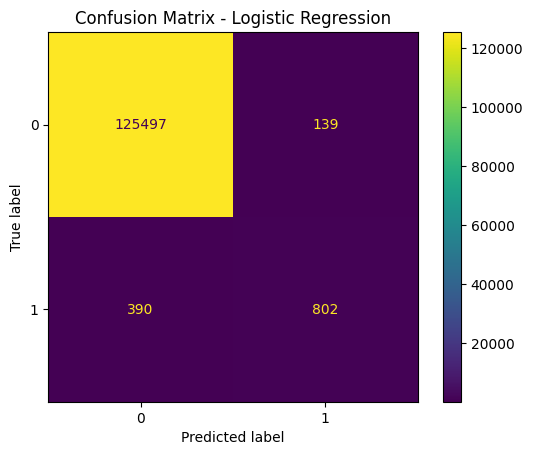

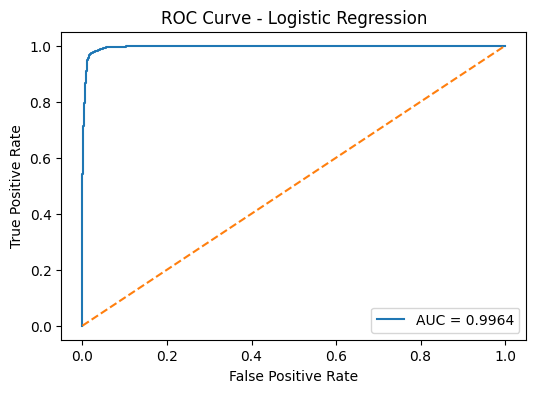


MODEL : Decision Tree
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000
ROC-AUC   : 1.0000


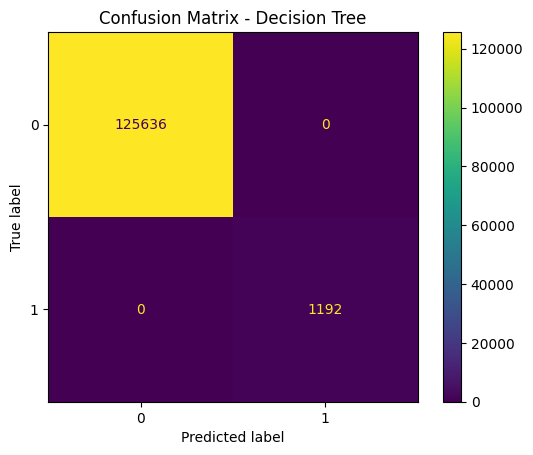

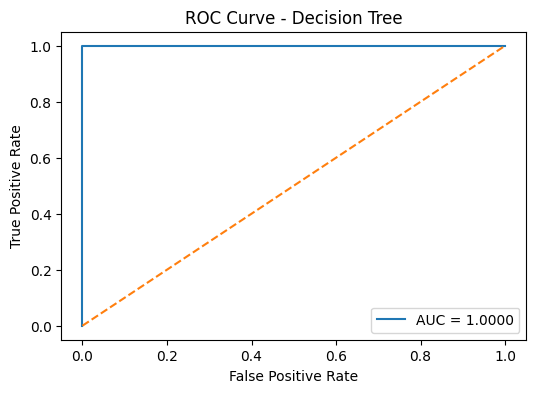


MODEL : Random Forest
Accuracy  : 1.0000
Precision : 0.9983
Recall    : 0.9992
F1 Score  : 0.9987
ROC-AUC   : 1.0000


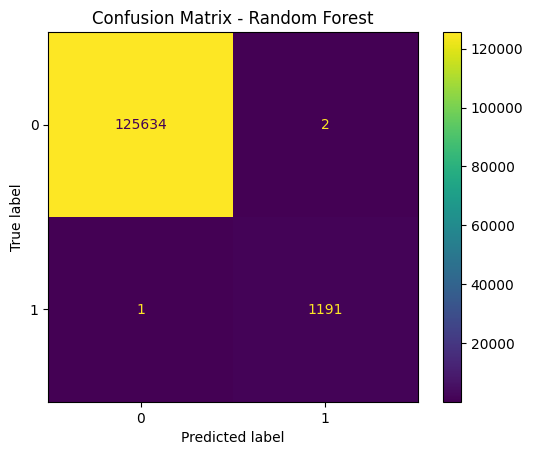

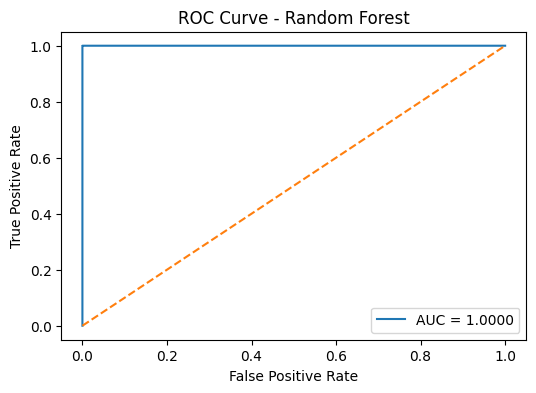


MODEL : Gradient Boosting
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000
ROC-AUC   : 1.0000


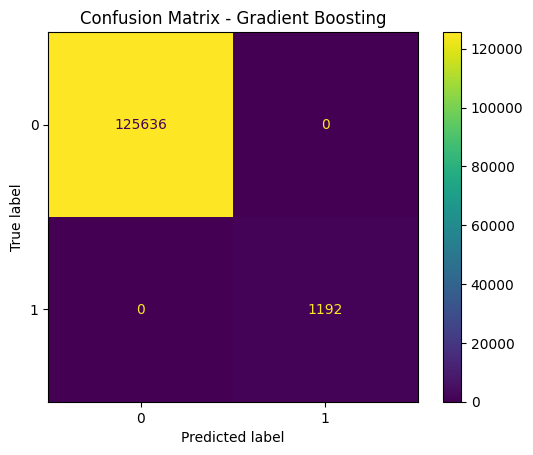

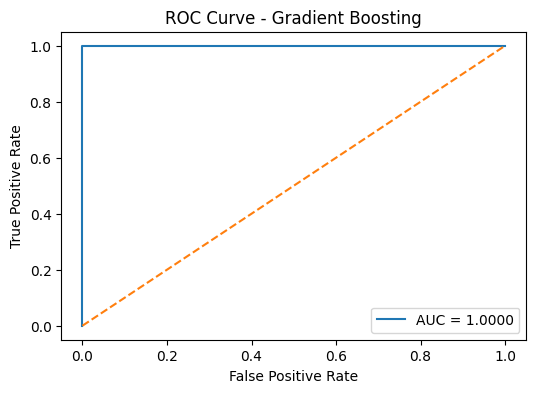


MODEL : XGBoost
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000
ROC-AUC   : 1.0000


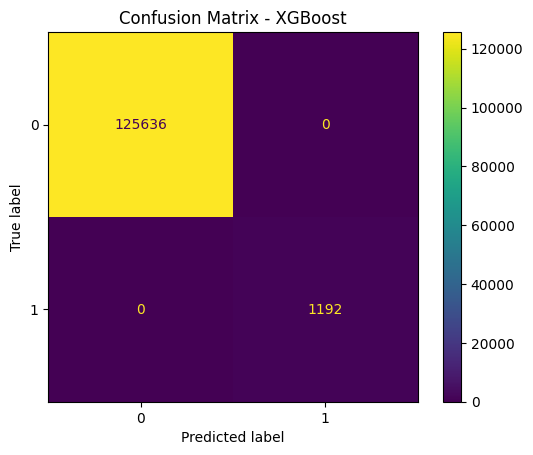

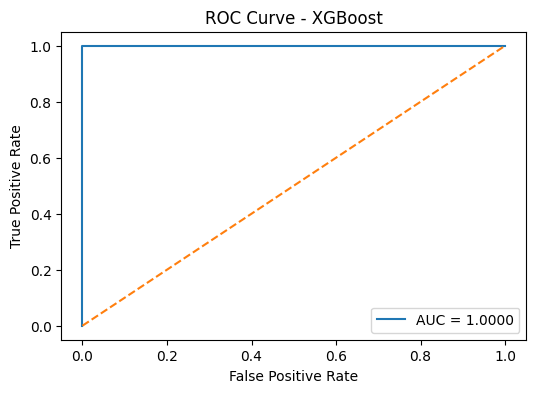

In [3]:
results = []

for name, model in models.items():

    print(f"\n{'='*50}")
    print(f"MODEL : {name}")
    print(f"{'='*50}")

    # Train
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Probabilities for ROC-AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = None

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    if y_prob is not None:
        auc = roc_auc_score(y_test, y_prob)
    else:
        auc = np.nan

    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")

    # Save results
    results.append([name, acc, prec, rec, f1, auc])

    # ==============================
    # Confusion Matrix
    # ==============================

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm
    )

    disp.plot()

    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    # ==============================
    # ROC Curve
    # ==============================

    if y_prob is not None:

        fpr, tpr, thresholds = roc_curve(
            y_test,
            y_prob
        )

        plt.figure(figsize=(6,4))
        plt.plot(fpr, tpr,
                 label=f"AUC = {auc:.4f}")

        plt.plot([0,1],[0,1],'--')

        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve - {name}")
        plt.legend()
        plt.show()